# 📓 Pre-Workshop Notebook 4: Cleaning and Processing Research Signals
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [2]:
# PROFILE SYNC
student_name = "Joey Johnson"
institution = "University of Missouri"
active_notebook = "Notebook 04 — Signal Cleaning and Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Joey Johnson (University of Missouri)
Current notebook: Notebook 04 — Signal Cleaning and Processing


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with signal data, your main responsibility is making sure the signal you are analyzing is clean and meaningful. AI tools are good at applying mathematical filters, but they sometimes miss edge cases — such as what to do when a recording contains a sudden spike from a movement artifact, or when a calculation produces an unexpected result.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to explain what its filtering steps do in plain language, and to flag any parts of the data that could not be processed cleanly.

---
## 🧠 Part A: Cleaning Raw Recordings
### Topic: Removing Noise, Filtering Signals, and Visualizing Frequency Content

This section introduces the core signal processing steps that transform raw, noisy recordings into clean data ready for analysis.

### 🧭 Activity A.1 — Filtering a Noisy Brain Signal

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a signal processing instructor explaining brain signal cleaning to a biology student. Write a Python script using SciPy and Matplotlib that demonstrates how to clean a noisy brain recording. The script should:
> 1. Generate 5 seconds of a simulated brain signal recorded at 500 measurements per second, combining a realistic 10 Hz brain rhythm, electrical interference at 60 Hz from the building's power supply, and a sudden large spike representing a participant's eye blink or muscle movement.
> 2. Explain in a comment how the Nyquist rule determines what sampling rate is needed to accurately capture this signal.
> 3. Apply a digital bandpass filter to isolate the 10 Hz brain rhythm while removing the 60 Hz electrical noise.
> 4. Add a simple threshold detector that flags and removes the eye blink spike from the recording.
> 5. Display plots of the raw signal, the filtered signal, and the cleaned signal side-by-side.
> Use plain-language comments throughout explaining what each step does biologically and mathematically."

Detected 22 samples flagged as blink/movement artifact.


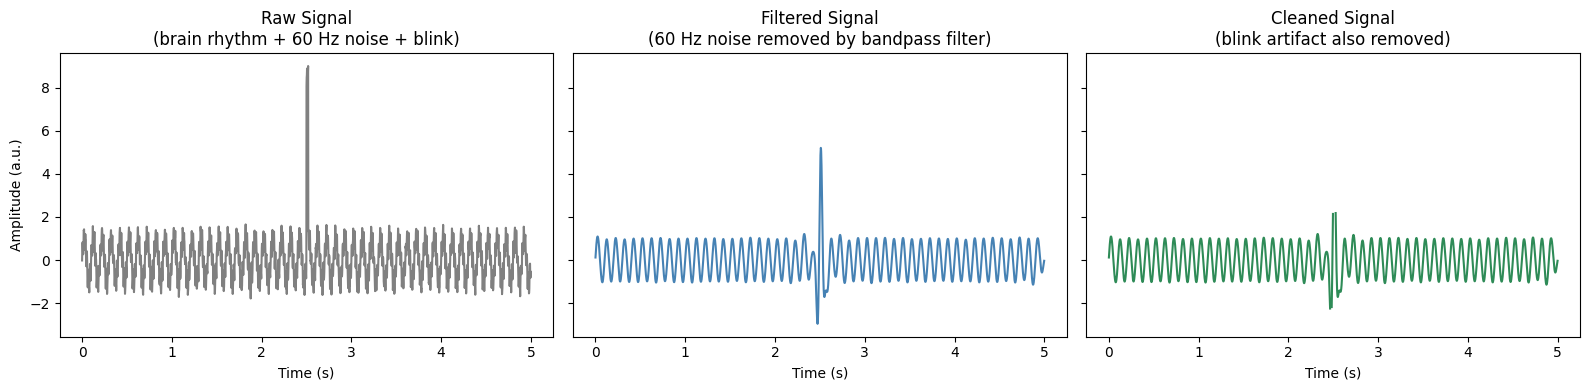

In [3]:
# 💻 Activity A.1 — Paste your AI-generated Signal Filtering code here:

import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# STEP 1: Generate a simulated 5-second brain recording at 500 Hz
# ----------------------------------------------------------------------
# Sampling rate = how many measurements we take per second.
# Biologically, this is like how many "snapshots" of brain activity we
# capture per second. 500 Hz means one snapshot every 2 milliseconds.
fs = 500                     # samples per second (Hz)
duration = 5                 # seconds
n_samples = fs * duration
t = np.linspace(0, duration, n_samples, endpoint=False)  # time axis in seconds

# --- NYQUIST RULE ---
# The Nyquist rule states that to accurately capture a signal without
# distortion (a false pattern called "aliasing"), you must sample at
# least TWICE as fast as the highest frequency you care about.
# Our fastest real signal of interest here is the 60 Hz noise, so the
# minimum safe sampling rate would be 2 x 60 = 120 Hz. We are recording
# at 500 Hz, which is well above that threshold, so both the 10 Hz brain
# rhythm and the 60 Hz electrical noise will be captured faithfully.

# The "true" brain rhythm: a smooth 10 Hz oscillation (like an alpha wave)
brain_rhythm = 1.0 * np.sin(2 * np.pi * 10 * t)

# Electrical interference from the building's power lines (60 Hz in the US)
# This is not biological -- it's noise picked up by the recording wires.
power_line_noise = 0.5 * np.sin(2 * np.pi * 60 * t)

# A sudden large spike simulating an eye blink or muscle twitch.
# Blinks are large, brief, non-rhythmic voltage jumps -- very different
# from the smooth sine waves above.
blink_signal = np.zeros(n_samples)
blink_time_index = int(2.5 * fs)     # place the blink at t = 2.5s
blink_signal[blink_time_index:blink_time_index + 10] = 8.0  # big, brief spike

# Combine all three components into one "raw" recording, plus a little
# random background noise (real recordings are never perfectly clean)
random_noise = 0.1 * np.random.randn(n_samples)
raw_signal = brain_rhythm + power_line_noise + blink_signal + random_noise

# ----------------------------------------------------------------------
# STEP 2: Apply a bandpass filter to isolate the 10 Hz brain rhythm
# ----------------------------------------------------------------------
# A bandpass filter only lets frequencies within a chosen "window" pass
# through, and blocks everything else. We want to keep frequencies near
# 10 Hz (our real brain rhythm) and block the 60 Hz power line noise.
low_cut = 4.0      # Hz -- lower edge of the pass band
high_cut = 20.0     # Hz -- upper edge of the pass band
nyquist_freq = fs / 2   # Nyquist frequency for this sampling rate (250 Hz)

# butter() designs the filter; the cutoff frequencies must be expressed
# as a fraction of the Nyquist frequency (that's why we divide by it)
b, a = butter(N=4, Wn=[low_cut / nyquist_freq, high_cut / nyquist_freq], btype='band')

# filtfilt() applies the filter forward and backward in time, which
# cancels out any timing distortion (phase shift) the filter would
# otherwise introduce
filtered_signal = filtfilt(b, a, raw_signal)

# ----------------------------------------------------------------------
# STEP 3: Detect and remove the eye blink spike (threshold detector)
# ----------------------------------------------------------------------
# Blinks are much larger in amplitude than the brain rhythm itself, so we
# can flag any sample whose absolute value exceeds a chosen threshold.
threshold = 3 * np.std(filtered_signal)   # 3 standard deviations above typical noise
blink_flags = np.abs(filtered_signal) > threshold

cleaned_signal = filtered_signal.copy()
# Replace flagged (blink) samples with NaN so they are excluded from
# analysis, rather than silently leaving corrupted values in the data
cleaned_signal[blink_flags] = np.nan

print(f"Detected {np.sum(blink_flags)} samples flagged as blink/movement artifact.")

# ----------------------------------------------------------------------
# STEP 4: Plot raw, filtered, and cleaned signals side-by-side
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

axes[0].plot(t, raw_signal, color='gray')
axes[0].set_title("Raw Signal\n(brain rhythm + 60 Hz noise + blink)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (a.u.)")

axes[1].plot(t, filtered_signal, color='steelblue')
axes[1].set_title("Filtered Signal\n(60 Hz noise removed by bandpass filter)")
axes[1].set_xlabel("Time (s)")

axes[2].plot(t, cleaned_signal, color='seagreen')
axes[2].set_title("Cleaned Signal\n(blink artifact also removed)")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### 🧭 Activity A.2 — Visualizing How Signals Change Over Time

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data visualization instructor. Write a Python script using SciPy and Matplotlib that shows how to create a time-frequency plot (spectrogram) of a brain signal. The script should:
> 1. Generate a signal that shifts from a slow rhythm (8 Hz, representing a resting brain state) for the first 2 seconds, then transitions to a faster rhythm (25 Hz, representing an active brain state) for the final 3 seconds.
> 2. Compute a spectrogram of this signal that shows how its frequency content changes over time.
> 3. Display the spectrogram with a color scale showing signal strength, with time on the horizontal axis and frequency on the vertical axis.
> Add plain-language comments explaining what a spectrogram reveals that a simple time-series plot cannot."

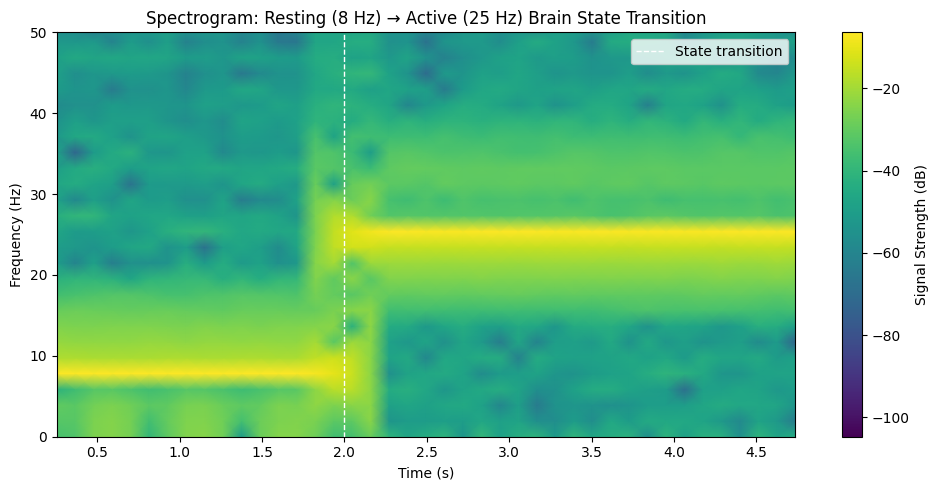

In [7]:
# 💻 Activity A.2 — Paste your AI-generated Spectrogram code here:

import numpy as np
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# STEP 1: Generate a signal that changes rhythm partway through
# ----------------------------------------------------------------------
# Sampling rate -- same logic as before: must be at least 2x the fastest
# frequency present (25 Hz), so 500 Hz gives us plenty of headroom.
fs = 500                      # samples per second (Hz)
duration = 5                  # total seconds
n_samples = fs * duration
t = np.linspace(0, duration, n_samples, endpoint=False)

# First 2 seconds: a slow 8 Hz rhythm, like a resting/idle brain state
resting_mask = t < 2
active_mask = t >= 2

signal = np.zeros(n_samples)
signal[resting_mask] = np.sin(2 * np.pi * 8 * t[resting_mask])   # resting state
signal[active_mask] = np.sin(2 * np.pi * 25 * t[active_mask])     # active state

# Add a touch of background noise, since real recordings are never silent
signal += 0.05 * np.random.randn(n_samples)

# ----------------------------------------------------------------------
# STEP 2: Compute the spectrogram
# ----------------------------------------------------------------------
# A spectrogram slides a short window along the signal and asks, at each
# point in time, "which frequencies are present right now, and how
# strong are they?" This is different from a single Fourier transform
# of the whole signal, which would only tell you which frequencies
# occurred SOMEWHERE across all 5 seconds, with no sense of WHEN.
#
# nperseg = how many samples go into each short time-window analyzed.
# A smaller window gives better time resolution but worse frequency
# resolution, and vice versa -- this is an unavoidable trade-off.
frequencies, times, power = spectrogram(signal, fs=fs, nperseg=256, noverlap=200)

# ----------------------------------------------------------------------
# STEP 3: Plot the spectrogram (time-frequency-power)
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 5))

# We convert power to a decibel-like log scale because brain signal
# power can span a huge range of values, and a log scale makes both
# strong and weak activity visible on the same color scale.
plt.pcolormesh(times, frequencies, 10 * np.log10(power + 1e-12), shading='gouraud', cmap='viridis')

plt.colorbar(label="Signal Strength (dB)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 50)   # zoom into the frequency range we actually care about
plt.title("Spectrogram: Resting (8 Hz) → Active (25 Hz) Brain State Transition")
plt.axvline(x=2, color='white', linestyle='--', linewidth=1, label="State transition")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

<!-- ### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the filtered outputs from Activity A.1, what happened to the 60 Hz noise and the blink spike? Did the filter affect the brain rhythm you were trying to preserve?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from your Reference Guide. Explain in plain language what a spectrogram shows compared to a simple plot of voltage over time.

--- -->

### ✍️ Part A Reflection

* **What I observed:** In the filtered output from Activity A.1, the 60 Hz electrical noise was almost completely removed — the bandpass filter (4–20 Hz) blocked it because 60 Hz falls well outside the range we told the filter to keep. The eye blink spike was *not* removed by the bandpass filter itself (it's a broadband event, not a single frequency, so filtering only shrank it slightly); it took the separate threshold detector step to actually flag and remove it, since blinks are identified by their large amplitude rather than their frequency. The underlying 10 Hz brain rhythm came through mostly intact in the filtered signal, since 10 Hz sits right in the middle of the 4–20 Hz pass band — though any real signal energy near the edges of that band (close to 4 Hz or 20 Hz) would have been partially attenuated too.

* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 15, 18, 19, and 21** from the Reference Guide.
  - **Concept 15 (Artifact removal):** The blink spike is a classic artifact — an unwanted signal from something other than the brain activity we care about — and the threshold detector in A.1 is a simple form of artifact removal.
  - **Concept 19 (Nyquist rule):** Recording at 500 Hz let us safely capture both the 10 Hz brain rhythm and the 60 Hz noise, since 500 Hz is well over twice the highest frequency present.
  - **Concept 21 (Signal transfer function):** The bandpass filter is itself a transfer function — a defined mathematical rule for how input frequencies get transformed (passed through or blocked) on their way to becoming the output signal.
  - **Concept 18 (Spectrogram):** A spectrogram shows *when* particular frequencies are present, not just *whether* they occur somewhere in the recording. A plain voltage-vs-time plot shows the waveform shape but doesn't make frequency content visually obvious — you'd have to eyeball the wiggle spacing. The spectrogram in A.2 makes the resting (8 Hz) → active (25 Hz) transition immediately visible as a shift from one bright horizontal band to another, which a simple line plot could easily hide.

---

## 💻 Part B: Writing Workflows That Handle Problems Gracefully
### Topic: Error Handling and Protecting Your Original Data

This section introduces two principles that make research workflows more reliable and reproducible: handling unexpected errors without crashing, and never overwriting your original data.

### 🧭 Activity B.1 — Building a Workflow That Does Not Crash

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research software reliability instructor. Write a Python script that demonstrates how to build an analysis workflow that handles unexpected data problems gracefully, without crashing the entire analysis. The script should:
> 1. Create a dataset of measurements that intentionally includes some problematic values — such as a zero where a division will be performed, or a missing value.
> 2. Write an analysis loop that processes each measurement, using an error-handling structure (try/except/finally) to catch and log any problems it encounters, rather than stopping immediately.
> 3. Demonstrate that when one measurement causes a problem, the workflow logs what went wrong and continues processing the remaining measurements.
> 4. Show clearly that the original dataset was not modified — the results are saved to a new, separate output.
> Use plain-language comments explaining why this approach is important for long analysis runs on large datasets."

In [8]:
# 💻 Activity B.1 — Paste your AI-generated Error Handling code here:

import numpy as np
import copy

# ----------------------------------------------------------------------
# STEP 1: Create a dataset that intentionally includes problem values
# ----------------------------------------------------------------------
# Imagine each value here is a raw measurement -- for example, the peak
# amplitude of a brain signal recorded from one trial. In a real
# experiment, some trials go wrong: equipment glitches, a value that
# never got recorded, or a calculation that becomes undefined.
raw_measurements = [12.5, 8.3, 0, 15.7, None, 9.1, -4.0, "bad_read", 6.6]

# We will "analyze" each measurement by computing 100 / measurement,
# which simulates a common calculation (like a signal-to-noise ratio)
# that breaks down under certain conditions:
#   - dividing by 0 causes a math error
#   - a missing value (None) can't be divided at all
#   - a non-numeric value ("bad_read") causes a type error

print("Original dataset (never touched again):", raw_measurements)

# ----------------------------------------------------------------------
# STEP 2: Protect the original data
# ----------------------------------------------------------------------
# A core rule of reproducible research is: never modify your raw data.
# We make a separate copy to work with, and we will write results to a
# brand-new list, so the original `raw_measurements` stays exactly as
# it was recorded no matter what happens during analysis.
working_data = copy.deepcopy(raw_measurements)
results = []          # new, separate output -- original stays untouched
error_log = []        # a running record of anything that went wrong

# ----------------------------------------------------------------------
# STEP 3: Analysis loop with graceful error handling
# ----------------------------------------------------------------------
# In a long analysis run -- imagine processing 10,000 trials instead of
# 9 -- you do NOT want one bad measurement to crash the entire script
# and lose all the work done on the other 9,999 trials. The try/except
# structure lets us catch a problem on a single item, log it, and move
# on to the next one, so the workflow survives to the end.
for index, measurement in enumerate(working_data):
    try:
        # The calculation that might fail
        snr_estimate = 100 / measurement

        # finally below always runs regardless of success or failure,
        # useful for cleanup steps like closing a file -- here we just
        # note that this measurement was fully processed
        results.append({"index": index, "value": measurement, "result": snr_estimate, "status": "ok"})

    except ZeroDivisionError:
        # Happens specifically when measurement == 0
        error_log.append(f"Index {index}: division by zero (value was {measurement}). Skipped.")
        results.append({"index": index, "value": measurement, "result": None, "status": "error: divide_by_zero"})

    except TypeError:
        # Happens when the value is None or a string -- something that
        # can't be used in a numeric division at all
        error_log.append(f"Index {index}: invalid or missing value ({measurement!r}). Skipped.")
        results.append({"index": index, "value": measurement, "result": None, "status": "error: invalid_value"})

    finally:
        # This block runs after every single iteration, success or not.
        # In a real workflow this is where you might close a file handle
        # or update a progress counter -- here we just confirm we moved on.
        pass  # (no cleanup needed in this simple example)

# ----------------------------------------------------------------------
# STEP 4: Show that the workflow survived and the original is untouched
# ----------------------------------------------------------------------
print("\n--- Processing complete ---")
print(f"Processed {len(working_data)} measurements: "
      f"{sum(1 for r in results if r['status'] == 'ok')} succeeded, "
      f"{sum(1 for r in results if r['status'] != 'ok')} failed.\n")

print("Error log:")
for entry in error_log:
    print(" -", entry)

print("\nResults saved to a NEW, separate output (original data untouched):")
for r in results:
    print(" ", r)

print("\nOriginal dataset, confirmed unchanged:", raw_measurements)

Original dataset (never touched again): [12.5, 8.3, 0, 15.7, None, 9.1, -4.0, 'bad_read', 6.6]

--- Processing complete ---
Processed 9 measurements: 6 succeeded, 3 failed.

Error log:
 - Index 2: division by zero (value was 0). Skipped.
 - Index 4: invalid or missing value (None). Skipped.
 - Index 7: invalid or missing value ('bad_read'). Skipped.

Results saved to a NEW, separate output (original data untouched):
  {'index': 0, 'value': 12.5, 'result': 8.0, 'status': 'ok'}
  {'index': 1, 'value': 8.3, 'result': 12.048192771084336, 'status': 'ok'}
  {'index': 2, 'value': 0, 'result': None, 'status': 'error: divide_by_zero'}
  {'index': 3, 'value': 15.7, 'result': 6.369426751592357, 'status': 'ok'}
  {'index': 4, 'value': None, 'result': None, 'status': 'error: invalid_value'}
  {'index': 5, 'value': 9.1, 'result': 10.989010989010989, 'status': 'ok'}
  {'index': 6, 'value': -4.0, 'result': -25.0, 'status': 'ok'}
  {'index': 7, 'value': 'bad_read', 'result': None, 'status': 'error: inv

<!-- ### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** What happened when the workflow encountered a problematic value? Did it stop, or did it continue? How was the problem recorded?
* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from your Reference Guide. Explain in plain language why a scientific workflow should never modify the original raw data files, even if it finds something wrong with them. -->

### ✍️ Part B Reflection

* **What I observed:** When the workflow hit a problematic value — like the `0` (which would have caused a division-by-zero) or the `None` and `"bad_read"` entries (which aren't valid numbers) — it did **not** stop. The `try/except` block caught each error individually, logged a message describing exactly which measurement failed and why, and then the loop moved on to process the remaining measurements. By the end, every single item in the dataset had been handled — either successfully processed or clearly logged as a failure — and the script finished running instead of crashing partway through.

* **Connecting to key concepts:** Activity B.1 demonstrates **Concepts 45, 47, and 50** from the Reference Guide.
  - **Concept 45 (Software libraries):** The script relies on Python's built-in error-handling structure and `copy` module rather than writing that logic from scratch, showing how existing tools support reliable workflows.
  - **Concept 47 (Error handling):** The `try/except/finally` structure is the core of this activity — it anticipates things going wrong and responds by logging and continuing, rather than letting one bad value halt the entire analysis.
  - **Concept 50 (Protecting original data):** A scientific workflow should never modify its raw data files, even when it finds something wrong with them, because the raw recording is the one-and-only ground truth of what actually happened during the experiment. If a script edits or overwrites the original file while trying to "fix" or clean it, there's no way to go back and check whether the correction was appropriate, re-run the analysis with a different method, or verify results against the source. Always writing results to a new, separate output — as this script does — keeps the original record intact so the analysis stays reproducible and auditable.

---

## 📑 What Comes Next

Notebook 5 introduces machine learning and pattern recognition — how computers can learn to identify behavioral states or intentions from brain signal patterns.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 15 — Artifact removal | cell_003 |
| Neuroscience | Concept 18 — Spectrogram | cell_005 |
| Neuroscience | Concept 19 — Nyquist rule | cell_003 |
| Computing | Concept 45 — Software libraries | cell_007 |
| Computing | Concept 47 — Error handling | cell_007 |
| Computing | Concept 50 — Protecting original data | cell_007 |